# Physics for Scientists & Engineers

<img src="..//pics/cover.jpg" width=400> 

In [1]:
from vpython import *
from astropy import units as u
from astropy import constants as const
import sympy as sp
from IPython.display import display, Math


<IPython.core.display.Javascript object>

In [2]:
pwd

'c:\\Users\\crodr\\BK_tech\\Physics\\BK_Physics_4_SE_Serway_11\\ch01'

## SECTION 1.5  Estimate and Order-of-Magnitude Calculations


#### Function to calculate the Order of Magnitude

In [ ]:
import math


def order_of_magnitude(number):
    if number == 0:
        return 0  # Order of magnitude undefined, 0 is a safe return
    num = abs(number)  # To deal with negative numbers
    # log10(n) = log10(mantissa * 10^exponent)
    exponent = floor(log10(num))
    mantissa = num / (10**exponent)

    # Threshold is the geometric mean of 1 and 10
    threshold = sqrt(10)  # Approximately 3.1622

    if mantissa >= threshold:
        return 10 ** (exponent + 1)
    else:
        return 10**exponent


In [ ]:
### --- Testing the function ---
test_values = {
    "Speed of Light": 299_792_458,
    "Elephant mass": 5_000,
    "Earth Radius": 6_371_000,
    "Proton Mass": 1.67e-27,
}

for name, val in test_values.items():
    oom = order_of_magnitude(val)
    print(f"{name:.<30} Order of Maginude: {oom:.0e}")


Speed of Light................ Order of Maginude: 1e+08
Elephant mass................. Order of Maginude: 1e+04
Earth Radius.................. Order of Maginude: 1e+07
Proton Mass................... Order of Maginude: 1e-27


### Problem 17

#### Problem statement

(a) Compute the order of magnitude of the mass of a bathtub half full of water. 

(b) Compute the order of magnitude of the mass of a bathtub half full of copper coins.

#### Answer

(a) We estimate the mass of the water in the bathtub. Assume the tub measures 1.3 m by 0.5 m by 0.3 m. One-half of its volume is then

$$ V = \frac{1}{2} l \times w \times h$$

The mass of the volume of waters is

$$m = \rho \times V$$

In [ ]:
l = 1.3 * u.m
w = 0.5 * u.m
h = 0.3 * u.m
density_water = 1_000 * u.kg / u.m**3

V_water = 1 / 2 * l * w * h
mass_water = density_water * V_water

# Compute the order of magnitude
rounded_number = order_of_magnitude(mass_water.value)

print(
    f"The mass water is {mass_water:.2e} that is the order of magnitude of {rounded_number:.0e} {mass_water.unit}."
)


The mass water is 9.75e+01 kg that is the order of magnitude of 1e+02 kg.


(b) The mass of the copper is

$$m_{copper} = \rho_{copper} \times V_{water}$$

In [ ]:
density_copper = 8_920 * u.kg / u.m**3
mass_copper = density_copper * V_water

# Compute the order of magnitude
nearest_number = order_of_magnitude(mass_copper.value)

print(
    f"The mass of copper is {mass_copper:.2e} that is the order of magnitude of {nearest_number:.0e} {mass_copper.unit}."
)


The mass of copper is 8.70e+02 kg that is the order of magnitude of 1e+03 kg.


### Problem 18

#### Problem statement
To an order of magnitude, how many piano tuners reside in New York City? The physicist Enrico Fermi was famous for asking questions like this one on oral Ph.D. qualifying examinations.

#### Answer
Assume a total population of $10^7$ people. Also, let us estimate that one persons in one hundred owns a piano. Assume that in one year a single piano turner can service about 1000 pianos (about 4 per day for 250 weekdays), and that each piano is tuned one per year.

Therefore, the number of tuners

$$ tuners = \left( \frac{1 \;tunner}{1000 \;pianos}\right) \left( \frac{1 \;piano}{100 \;people}\right) \left( 10^7 \; people\right)$$

In [ ]:
tuners = (1 / 1000) * (1 / 100) * 10**7

print(f"the number of tuners in New York is in the order of {tuners:.0f}")


the number of tuners in New York is in the order of 100


### Problem 19

#### Problem statement
Your roommate is playing a video game from the latest Star Wars movie while you are studying physics. Distracted by the noise, you go to see what is on the screen. The game involves trying to fly a spacecraft through a crowded field of asteroids in the asteroid belt around the Sun. You say to him,
“Do you know that the game you are playing is very unrealistic? The asteroid belt is not that crowded and you don’t have to maneuver through it like that!” Distracted by your statement, he accidentally allows his spacecraft to strike an asteroid, just missing the high score. He turns to you in disgust and says, “Yeah, prove it.” You say, “Okay, I’ve learned recently that the highest concentration of asteroids is in a doughnut-shaped
region between the Kirkwood gaps at radii of 2.06 AU and 3.27 AU from the Sun. There are an estimated $10^9$ asteroids of radius 100 m or larger, like those in your video game, in this region . . .” Finish your argument with a calculation to show that the number of asteroids in the space near a spacecraft is tiny. 



#### Answer

The volume of a doughnut-shaped region, also known as a torus, can be calculated using the formula for the volume of a torus:

$$ V = 2\pi^2(Rr^2) $$

where:
- `R` is the distance from the center of the hole to the center of the tube (the average of the outer and inner radii), and
- `r` is the radius of the tube (half the difference of the outer and inner radii).

In this case, the radii of the Kirkwood gaps are given in Astronomical Units (AU), where 1 AU is approximately equal to $1.496 \times 10^{11}$ meters.

Let's calculate:
- The outer radius (`R_o`) is 3.27 AU,
- The inner radius (`R_i`) is 2.06 AU,
- So, `R = (R_o + R_i) / 2`, and
- `r = (R_o - R_i) / 2`.


In [ ]:
import numpy as np

# Constants

R_o = 3.27 * u.au  # Outer radius in meters
R_i = 2.06 * u.au  # Inner radius in meters

# Calculate R and r
R = (R_o + R_i) / 2
r = (R_o - R_i) / 2

# Calculate the volume of the torus
V = 2 * np.pi**2 * R * r**2

# Number of asteroids
N = 10**9

# Average volume per asteroid
V_avg = V / N

# Average distance between two asteroids, cubic root of volume
d_avg = V_avg ** (1 / 3)
d_avg_km = d_avg.to(u.km)
nearest_number = order_of_magnitude(d_avg_km.value)


print(f"The average distance between two asteroids is: {d_avg_km:,.0f}")
print(f"An Order of Magnitude of {nearest_number:.0e} km")


The average distance between two asteroids is: 400,963 km
An Order of Magnitude of 1e+06 km


#### Plot the Torus Region

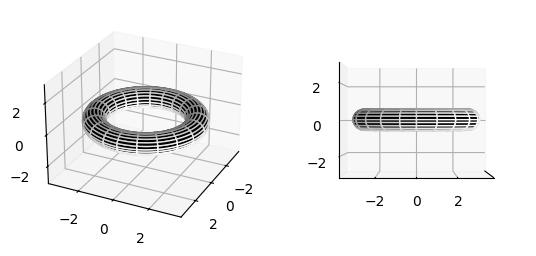

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Constants for the torus
r = 1 * u.au
AU = r.value
R = (R_o + R_i) / 2 / AU  # Average radius in AU
r = (R_o - R_i) / 2 / AU  # Tube radius in AU

# Create a grid for the torus
theta = np.linspace(0, 2.0 * np.pi, 100)
phi = np.linspace(0, 2.0 * np.pi, 100)
theta, phi = np.meshgrid(theta, phi)
c, a = R, r
x = (c + a * np.cos(theta)) * np.cos(phi)
y = (c + a * np.cos(theta)) * np.sin(phi)
z = a * np.sin(theta)

# Create a 3D plot
fig = plt.figure()
ax1 = fig.add_subplot(121, projection="3d")
ax1.set_zlim(-3, 3)
ax1.plot_surface(x, y, z, rstride=5, cstride=5, color="k", edgecolors="w")
# ax1.view_init(10, 26)
ax1.view_init(27, 26)
ax2 = fig.add_subplot(122, projection="3d")
ax2.set_zlim(-3, 3)
ax2.plot_surface(x, y, z, rstride=5, cstride=5, color="k", edgecolors="w")
ax2.view_init(0, 0)
ax2.set_xticks([])
plt.show()


In [ ]:
import numpy as np
import plotly.graph_objects as go

# Constants for the torus

R_o = 3.27 * u.au  # Outer radius in meters
R_i = 2.06 * u.au  # Inner radius in meters

# Create a grid for the torus
theta = np.linspace(0, 2.0 * np.pi, 100)
phi = np.linspace(0, 2.0 * np.pi, 100)
theta, phi = np.meshgrid(theta, phi)
c, a = R, r
x = (c + a * np.cos(theta)) * np.cos(phi)
y = (c + a * np.cos(theta)) * np.sin(phi)
z = a * np.sin(theta)

# Create a 3D plot
fig = go.Figure(data=[go.Surface(x=x, y=y, z=z)])
# fig.update_layout(scene=dict(aspectratio=dict(x=1, y=1, z=1)))
fig.update_layout(scene=dict(aspectmode="data"), title="3D Plot with Equal Proportions")

fig.show()
